<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 9: Discrete Fourier Transform (DFT)

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#frequency_content" style="color:black;">From Waveforms to Frequency Content</a></li>
    <li><a href="#background_inner" style="color:#1B5E20;"><strong>Background:</strong> The Geometric Meaning of Inner Products</a></li>
    <li><a href="#inner" style="color:black;">Inner Products and Complex Exponentials</a></li>
    <li><a href="#dft" style="color:black;">The DFT: Definition and Interpretation</a></li>
    <li><a href="#dftmatrix" style="color:black;">DFT Matrix and Inverse DFT</a></li>
    <li><a href="#background_complexity" style="color:#1B5E20;"><strong>Background:</strong> Algorithmic Complexity and the Value of Speed</a></li>
    <li><a href="#fft" style="color:black;">Fast Fourier Transform (FFT)</a></li>
    <li><a href="#exercise_leakage" style="color:#006064;"><strong>Exercise 1:</strong> Frequency Bins and Spectral Leakage</a></li>
    <li><a href="#exercise_missing_time" style="color:#006064;"><strong>Exercise 2:</strong> Missing Time Localization</a></li>
    <li><a href="#exercise_spectral_modification" style="color:#006064;"><strong>Exercise 3:</strong> Spectral Modification and Reconstruction</a></li>
</ul>

<a id="learn"></a>

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
A waveform shows how a signal changes over time, but it may not clearly reveal the oscillations from which the signal is built. <strong>Fourier analysis</strong> provides another perspective by representing a signal as a weighted superposition of sinusoids. The resulting <strong>frequency representation</strong>, or spectrum, reveals which frequencies occur and how strongly they contribute. In this unit, we study the <strong>discrete Fourier transform</strong> (DFT), which analyzes finite discrete-time signals. Building on complex exponentials and roots of unity from <a href="PCP_07_exp.html">Unit 7</a> and sampled signals from <a href="PCP_08_signal.html">Unit 8</a>, we interpret each Fourier coefficient as an inner product that compares the signal with a particular complex oscillation. We then examine the magnitude and phase of these coefficients, express the DFT as a matrix, reconstruct signals using the inverse DFT, and study the <strong>fast Fourier transform</strong> (FFT), which computes the same result much more efficiently. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Interpret an inner product as a comparison between finite signals.</li>
<li>Explain the DFT as a comparison with sampled complex exponentials.</li>
<li>Relate DFT indices to physical frequencies and interpret positive and negative frequencies.</li>
<li>Interpret the magnitude and phase of Fourier coefficients.</li>
<li>Explain frequency resolution, conjugate symmetry, and spectral leakage.</li>
<li>Construct the DFT matrix and reconstruct a signal using the inverse DFT.</li>
<li>Explain why the FFT is substantially faster than a direct DFT computation.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_leakage">Exercise 1</a>: Explore frequency bins and spectral leakage.</li>
<li><a href="#exercise_missing_time">Exercise 2</a>: Investigate the loss of time localization and its connection to the <a href="https://www.audiolabs-erlangen.de/resources/MIR/FMP/C2/C2_STFT-Basic.html">short-time Fourier transform</a>.</li>
<li><a href="#exercise_spectral_modification">Exercise 3</a>: Modify Fourier coefficients, reconstruct the signal, and examine the audible result.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
The time-domain signal and its frequency-domain representation contain the same information but organize it differently. <strong>The DFT replaces the question “What happens at each moment?” with “Which oscillations are present?”</strong>
</p>

</div>


In [20]:
# --- Core scientific stack ---
import numpy as np
from matplotlib import pyplot as plt
import timeit

# --- Custom utilities (Unit 9) ---
from libpcp.unit09 import (
    generate_sinusoid,
    generate_example_signal,
    exercise_freq_index,
    exercise_missing_time,
    exercise_chirp,
    exercise_inverse
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="frequency_content"></a>

## From Waveforms to Frequency Content

In <a href="PCP_08_signal.html#interference">Unit 8</a>, we constructed more complex signals by adding simpler ones. Consider, for example, the signal

$$
\begin{aligned}
f(t)
={}&0.8\sin\bigl(2\pi(1.9t-0.3)\bigr)\\
&+0.5\sin\bigl(2\pi(6.1t-0.1)\bigr)\\
&+0.3\sin\bigl(2\pi(16t-0.2)\bigr).
\end{aligned}
$$

Its three components have different frequencies, amplitudes, and phases. When shown separately, their oscillations are easy to recognize. After they are added, however, the individual contributions are much harder to identify in the resulting waveform.

The waveform is a complete description of the signal, but it emphasizes when the signal values change rather than which oscillations are present. A **frequency representation**, or **spectrum**, reorganizes the same information according to frequency. For the example above, we would expect prominent contributions near $1.9$, $6.1$, and $16$ Hz, with strengths related to their amplitudes.

If the components are known, constructing the signal is easy: we simply add them. Fourier analysis addresses the reverse problem. Given only the resulting waveform, it asks which oscillations are present and how strongly each one contributes. The following figure illustrates this change in difficulty by showing the three simple components and their more complicated superposition. To solve the reverse problem, we will need a mathematical way to compare a signal with a candidate oscillation. This comparison is provided by the **inner product**.

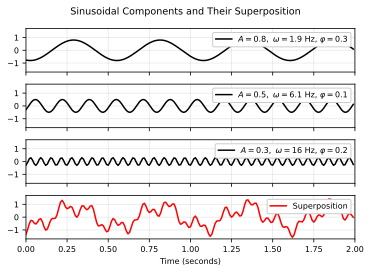

In [21]:
dur, sr = 2, 100
parameters = [
    (0.8, 1.9, 0.3),
    (0.5, 6.1, 0.1),
    (0.3, 16, 0.2),
]

components = [
    generate_sinusoid(dur=dur, amp=amp, freq=freq,
                      phase=phase, sr=sr)[0]
    for amp, freq, phase in parameters
]
x, t = generate_example_signal(dur=dur, sr=sr)

fig, axes = plt.subplots(
    4, 1, figsize=(5.2, 3.8), layout='tight',
    sharex=True, sharey=True
)
fig.suptitle('Sinusoidal Components and Their Superposition')

for ax, signal, (amp, freq, phase) in zip(
        axes[:3], components, parameters):
    label = rf'$A={amp:g},\ \omega={freq:g}$ Hz, $\varphi={phase:g}$'
    ax.plot(t, signal, color='black', label=label)
    ax.legend(loc='upper right', framealpha=1, facecolor='white')

axes[3].plot(t, x, color='red', label='Superposition')
axes[3].legend(loc='upper right', framealpha=1, facecolor='white')

for ax in axes:
    ax.set_xlim(0, dur)
    ax.set_ylim(-1.7, 1.7)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (seconds)');

The first three panels reveal the ingredients from which the signal is constructed. In the red superposition, the same information is still present, but it is no longer easy to recognize directly. To recover the hidden components, we will compare the sampled signal with oscillations of different frequencies. Before applying this idea to Fourier analysis, the following background box introduces the inner product as a general tool for comparing vectors.

<a id="background_inner"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding: 10px 20px;
  margin: 10px 0;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: The Geometric Meaning of Inner Products
</h2>

<div style="
  float:right;
  width:280px;
  max-width:48%;
  margin-left:20px;
  margin-bottom:10px;
  border:2px solid #1B5E20;
  padding:4px;
  background-color:white;
">
<img src="data/PCP_fig_inner_product.png"
     style="display:block; width:100%; height:auto;"
     alt="Geometric interpretation of inner products">
</div>

<p style="color:#1B5E20;">
Linear algebra allows us to treat a finite sequence of numbers as a vector. A vector with two or three coordinates can be drawn as an arrow. A signal with thousands of samples cannot, but the same geometric ideas still apply: it has a length, points in a direction, and can be compared with other vectors. Geometry therefore continues to work even when we can no longer draw the space. For real vectors $x,y\in\mathbb{R}^N$, the <strong>inner product</strong> is
$$
\langle x,y\rangle:=\sum_{n=0}^{N-1}x(n)y(n).
$$
The individual products reinforce or cancel one another, and their sum provides a single number describing the relationship between the vectors. The inner product determines the length, or <strong>norm</strong>, through $\|x\|:=\sqrt{\langle x,x\rangle}$. For nonzero vectors, it also determines their angle $\varphi$:
$$
\cos(\varphi)
=\frac{\langle x,y\rangle}{\|x\|\,\|y\|}.
$$
The normalized value is $1$ for the same direction, $-1$ for opposite directions, and $0$ for perpendicular directions. Perpendicular vectors are called <strong>orthogonal</strong>. Normalization matters because a large inner product may otherwise result simply from long vectors rather than similar directions.
</p>

<p style="color:#1B5E20;">
The complex numbers extend the real numbers, and the inner product can likewise be extended to complex vectors. This will be essential for Fourier analysis, where oscillations are represented by complex exponentials. For $x,y\in\mathbb{C}^N$, we use
$$
\langle x,y\rangle
:=\sum_{n=0}^{N-1}x(n)\overline{y(n)}.
$$
The conjugation ensures that $\langle x,x\rangle=\sum_{n=0}^{N-1}|x(n)|^2$ is real and nonnegative and can therefore still represent a squared length. Complex geometry is harder to visualize, but the main interpretation remains: the normalized magnitude $|\langle x,y\rangle|/(\|x\|\,\|y\|)$ lies between $0$ and $1$. Values near $1$ indicate strong alignment, while a value of $0$ means that the vectors are orthogonal and point in independent directions.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
The inner product also measures the <strong>component</strong> of one vector in a chosen direction. If $\|y\|=1$, the coefficient $\langle x,y\rangle$ describes how strongly $x$ is aligned with $y$. This interpretation remains valid when vectors represent audio signals, images, or other data rather than visible arrows. In Fourier analysis, the signal is the vector being examined, and the chosen directions are complex oscillations of different frequencies. <strong>A Fourier coefficient measures the contribution of one such oscillation to the signal.</strong>
</p>

<div style="clear:both;"></div>
</div>


<a id="inner"></a>

## Comparing Signals with Complex Exponentials

The background box introduced the inner product as a geometric tool for comparing vectors. We now apply this idea to finite signals. Let

$$
x=\bigl(x(0),x(1),\ldots,x(N-1)\bigr)^\top\in\mathbb{R}^N
$$

contain $N$ samples recorded at a sampling rate $F_{\mathrm{s}}$. The sample with index $n$ corresponds to the time $t_n=n/F_{\mathrm{s}}$.

To test whether $x$ contains an oscillation of frequency $\omega$, we construct the complex vector

$$
e_\omega(n)
:=\exp\left(2\pi i\omega\frac{n}{F_{\mathrm{s}}}\right),
\qquad n=0,\ldots,N-1.
$$

According to Euler’s formula,

$$
e_\omega(n)
=
\cos\left(2\pi\omega\frac{n}{F_{\mathrm{s}}}\right)
+i\sin\left(2\pi\omega\frac{n}{F_{\mathrm{s}}}\right).
$$

A single complex exponential therefore combines a cosine and sine of the same frequency. We compare it with the signal using

$$
c(\omega)
:=\langle x,e_\omega\rangle
=\sum_{n=0}^{N-1}x(n)\overline{e_\omega(n)}.
$$

For a real-valued signal,

$$
c(\omega)
=
\left\langle x,\operatorname{Re}(e_\omega)\right\rangle
-i\left\langle x,\operatorname{Im}(e_\omega)\right\rangle.
$$

The real and imaginary parts contain the comparisons with the cosine and sine. Combining them through the magnitude $|c(\omega)|$ gives an overall measure of how strongly the signal matches this frequency, without first having to select a particular phase. To remove the influence of vector length, we use the normalized comparison

$$
s(\omega)
:=\frac{|\langle x,e_\omega\rangle|}
        {\|x\|\,\|e_\omega\|},
\qquad 0\leq s(\omega)\leq1.
$$

We now repeat this comparison for many frequencies between $0$ and $20$ Hz. Since the example signal was constructed from components at $1.9$, $6.1$, and $16$ Hz, we expect large values near these frequencies. This frequency scan already captures the basic idea of Fourier analysis: test many oscillations and record how strongly each one matches the signal. The DFT will formalize this idea by selecting a specific finite grid of frequencies.

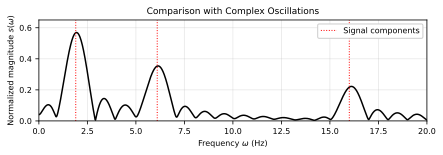

In [24]:
dur, sr = 1, 100
x, t = generate_example_signal(dur=dur, sr=sr)

frequencies = np.linspace(0, 20, 1001)
similarities = np.zeros(len(frequencies))

for k, freq in enumerate(frequencies):
    e = np.exp(2j * np.pi * freq * t)
    similarities[k] = (
        abs(np.vdot(e, x))
        / (np.linalg.norm(x) * np.linalg.norm(e))
    )

plt.figure(figsize=(6.2, 2.2), layout='tight')
plt.plot(frequencies, similarities, color='black')

for k, freq in enumerate([1.9, 6.1, 16]):
    plt.axvline(
        freq, color='red', linestyle=':', linewidth=1,
        label='Signal components' if k == 0 else None,
    )

plt.title('Comparison with Complex Oscillations')
plt.xlabel(r'Frequency $\omega$ (Hz)')
plt.ylabel(r'Normalized magnitude $s(\omega)$')
plt.xlim(0, 20)
plt.ylim(0, 0.65)
plt.grid(alpha=0.3)
plt.legend(loc='upper right', framealpha=1);

In [ ]:
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> One can use the NumPy function <code>np.vdot</code> to compute the inner product. However, opposed to the mathematical convention that conjugates the second argument, this function applies complex conjugation on the first argument. Therefore, for computing $\langle x | y \rangle$ as defined above, one has to call <code>np.vdot(y, x)</code>.
</div>

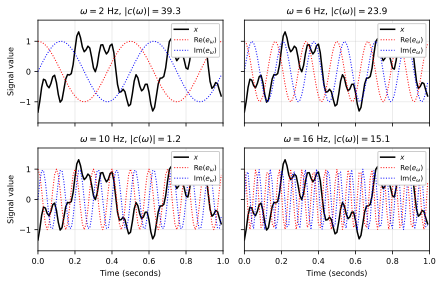

In [23]:
def plot_inner_product(ax, t, x, freq, sr):
    """Compare a signal with a sampled complex exponential."""
    e = np.exp(2j * np.pi * freq * t)
    coefficient = np.vdot(e, x)

    ax.plot(t, x, color='black', linewidth=1.5, label='$x$')
    ax.plot(t, e.real, 'r:', linewidth=1, label=r'$\operatorname{Re}(e_\omega)$')
    ax.plot(t, e.imag, 'b:', linewidth=1, label=r'$\operatorname{Im}(e_\omega)$')
    ax.set_title(
        rf'$\omega={freq:g}$ Hz, $|c(\omega)|={abs(coefficient):.1f}$'
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.7, 1.7)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=7, framealpha=1)


# Use the first second of the running example
dur, sr = 1, 100
x, t = generate_example_signal(dur=dur, sr=sr)

fig, axes = plt.subplots(
    2, 2, figsize=(6.2, 4), layout='tight',
    sharex=True, sharey=True
)

for ax, freq in zip(axes.flat, [2, 6, 10, 16]):
    plot_inner_product(ax, t, x, freq, sr)

for ax in axes[-1]:
    ax.set_xlabel('Time (seconds)')
for ax in axes[:, 0]:
    ax.set_ylabel('Signal value')

In the following, we generate and visualize three signals $x_1$, $x_2$, $x_3$. Then, we compute and discuss different inner products using the signals.

In [22]:
sr = 64
dur = 1
x1, t = generate_example_signal(Fs=Fs, dur=dur)
x2, t = generate_sinusoid(dur=dur, Fs=Fs, amp=1, freq=2, phase=0.3)
x3, t = generate_sinusoid(dur=dur, Fs=Fs, amp=1, freq=6, phase=0.1)

def plot_inner_product(ax, t, x, y, col_x='k', col_y='r', lab_x='x', lab_y='y'):
    """Plot inner product

    Notebook: PCP_09_dft.ipynb

    Args:
        ax: Axis handle
        t: Time axis
        x: Signal x
        y: Signal y
        col_x: Color of signal x (Default value = 'k')
        col_y: Color of signal y (Default value = 'r')
        lab_x: Label of signal x (Default value = 'x')
        lab_y: Label of signal y (Default value = 'y')
    """
    ax.plot(t, x, color=col_x, linewidth=1.0, linestyle='-', label=lab_x)
    ax.plot(t, y, color=col_y, linewidth=1.0, linestyle='-', label=lab_y)
    ax.set_xlim([0, t[-1]])
    ax.set_ylim([-1.5, 1.5])
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Amplitude')
    sim = np.vdot(y, x)
    ax.set_title(r'$\langle$ %s $|$ %s $\rangle = %.1f$' % (lab_x, lab_y, sim))
    ax.legend(loc='upper right')    

plt.figure(figsize=(6.2, 4), layout='tight')
ax = plt.subplot(2, 2, 1)
plot_inner_product(ax, t, x1, x1, col_x='k', col_y='k', lab_x='$x_1$', lab_y='$x_1$')
ax = plt.subplot(2, 2, 2)
plot_inner_product(ax, t, x1, x2, col_x='k', col_y='r', lab_x='$x_1$', lab_y='$x_2$')
ax = plt.subplot(2, 2, 3)
plot_inner_product(ax, t, x1, x3, col_x='k', col_y='b', lab_x='$x_1$', lab_y='$x_3$')
ax = plt.subplot(2, 2, 4)
plot_inner_product(ax, t, x2, x3, col_x='r', col_y='b', lab_x='$x_2$', lab_y='$x_3$')

TypeError: generate_example_signal() got an unexpected keyword argument 'Fs'

In the above example, one can make the following observations:

* The signal $x_1$ is similar to itself, leading to a large value of $\langle x_1 | x_1 \rangle=40.0$.
* The overall course of the signal $x_1$ strongly correlates with the sinusoid $x_2$, which is reflected by a relatively large value of $\langle x_1 | x_2 \rangle=29.9$.
* There are some finer oscillations of $x_1$ that are captured by $x_3$, leading to a still noticeable value of  $\langle x_1 | x_3 \rangle=14.7$. 
* The two sinusoids $x_2$ and $x_3$ are more or less uncorrelated, which is revealed by the value of $\langle x_2 | x_3 \rangle\approx 0$. 

In other words, the above comparison reveals that the signal $x_1$ has a strong signal component of $2~\mathrm {Hz}$ (frequency of $x_2$) and $6~\mathrm {Hz}$ (frequency of $x_3$). Measuring correlations between an arbitrary signal and sinusoids of different frequencies is exactly the idea of performing a Fourier (or spectral) analysis. 

<a id='dft'></a> 
## Definition of DFT

Let $x\in \mathbb{C}^N$ be a vector of length $N\in\mathbb{N}$. The **discrete Fourier transform** (DFT) of $x$ is defined by:

$$ X(k) := \sum_{n=0}^{N-1} x(n) \exp(-2 \pi i k n / N) $$

for $k \in [0:N-1]$. The vector $X\in\mathbb{C}^N$ can be interpreted as a frequency representation of the time-domain signal $x$.   To obtain a geometric interpretation of the DFT, we define the vector $\mathbf{e}_k \in\mathbb{C}^N$ with real part $\mathbf{c}_k=\mathrm{Re}(\mathbf{e}_k)$ and imaginary part $\mathbf{s}_k=\mathrm{Im}(\mathbf{e}_k)$ by

$$\mathbf{e}_k(n) :=  \exp(2 \pi i k n / N) = \cos(2 \pi i k n / N) + i \sin(2 \pi i k n / N)
= \mathbf{c}_k(n) + i \mathbf{s}_k(n)$$

for each $k \in [0:N-1]$.


This vector can be regarded as a [sampled version](PCP_08_signal.html) of the [exponential function](PCP_07_exp.html) of frequency $k/N$. Using inner products, the DFT can be expressed as

$$ X(k) = \sum_{n=0}^{N-1} x(n) \overline{\mathbf{e}_k}(n) = \langle x | \mathbf{e}_k \rangle,$$

thus measuring the similarity between the signal $x$ and the sampled exponential functions $\mathbf{e}_k$. The absolute value $|X(k)|$ indicates the degree of similarity between the signal $x$ and $\mathbf{e}_k$. In the case that $x\in \mathbb{R}^N$ is a real-valued vector (which is typically the case for audio signals), we obtain:

$$ 
X(k) = \langle x |\mathrm{Re}(\mathbf{e}_k) \rangle - i\langle x | \mathrm{Im}(\mathbf{e}_k) \rangle
= \langle x |\mathbf{c}_k \rangle - i\langle x | \mathbf{s}_k \rangle
$$

The following plot shows an example signal $x$ compared with functions $\overline{\mathbf{e}_k}$ for various frequency parameters $k$. The real and imaginary part of $\overline{\mathbf{e}_k}$ are shown in <font color='red'> red</font> and <font color='blue'> blue</font>, respectively.

In [ ]:
def plot_signal_e_k(ax, x, k, show_e=True, show_opt=False):
    """Plot signal and k-th DFT sinusoid

    Notebook: PCP_09_dft.ipynb

    Args:
        ax: Axis handle
        x: Signal
        k: Index of DFT
        show_e: Shows cosine and sine (Default value = True)
        show_opt: Shows cosine with optimal phase (Default value = False)
    """
    N = len(x)
    time_index = np.arange(N)
    ax.plot(time_index, x, 'k', marker='.', markersize='9', linewidth=2.0, 
            label='$x$')
    plt.xlabel('Time (samples)')
    e_k = np.exp(2 * np.pi * 1j * k * time_index / N)
    c_k = np.real(e_k)
    s_k = np.imag(e_k)
    X_k = np.vdot(e_k, x)

    plt.title(r'k = %d: Re($X(k)$) = %0.2f, Im($X(k)$) = %0.2f, $|X(k)|$=%0.2f' %
              (k, X_k.real, X_k.imag, np.abs(X_k)))
    if show_e is True:
        ax.plot(time_index, c_k, 'r', marker='.', markersize='4',
                 linewidth=1.0, linestyle=':', 
                 label=r'$\mathrm{Re}(\overline{\mathbf{u}}_k)$')
        ax.plot(time_index, s_k, 'b', marker='.', markersize='4',
                 linewidth=1.0, linestyle=':', 
                 label=r'$\mathrm{Im}(\overline{\mathbf{u}}_k)$')
    if show_opt is True:
        phase_k = - np.angle(X_k) / (2 * np.pi)
        cos_k_opt = np.cos(2 * np.pi * (k * time_index / N - phase_k))
        d_k = np.sum(x * cos_k_opt)
        ax.plot(time_index, cos_k_opt, 'g', marker='.', markersize='4',
                 linewidth=1.0, linestyle=':', label=r'$\cos_{k, opt}$')
    plt.grid()
    plt.legend(loc='lower right')


N = 64
x, t = generate_example_signal(Fs=N, dur=1)

for k in range(1, 8):
    fig, ax = plt.subplots(figsize=(6.2, 2.0), layout='tight')
    plot_signal_e_k(ax, x, k=k)

<a id='phase'></a>
## DFT Phase

At first sight, the DFT may be a bit confusing: Why is a real-valued signal $x$ compared with a complex-valued sinusoid $\mathbf{e}_k$? What does the resulting complex-valued Fourier coefficient

$$
c_k:= X(k) := \langle x |\mathrm{Re}(\mathbf{e}_k) \rangle - i\langle x | \mathrm{Im}(\mathbf{e}_k) \rangle. 
$$

encode? To understand this, we represent the complex number $c_k$ in form of its [polar representation](PCP_06_complex.html#polar)

$$
c_k = |c_k| \cdot \mathrm{exp}(i \gamma_k),    
$$

where $\gamma_k$ is the [angle](PCP_06_complex.html) (given in radians).  Furthermore, let $\mathbf{cos}_{k,\varphi}:[0:N-1]\to\mathbb{R}$ be a sampled sinusoid with frequency parameter $k$ and phase $\varphi\in[0,1)$, defined by

$$
   \mathbf{cos}_{k,\varphi}(n) = \mathrm{cos}\big( 2\pi (kn/N - \varphi) \big)
$$

for $n\in[0,N-1]$. Defining $\varphi_k := - \frac{\gamma_k}{2 \pi}$, one obtains the following remarkable property of the Fourier coefficient $c_k$: 

\begin{eqnarray*}
|c_k| &=& \mathrm{max}_{\varphi\in[0,1)} \langle x | \mathbf{cos}_{k,\varphi} \rangle,\\
\varphi_k  &=& \mathrm{argmax}_{\varphi\in[0,1)} \langle x | \mathbf{cos}_{k,\varphi} \rangle.
\end{eqnarray*}

In other words, the phase $\varphi_k$ maximizes the correlation between $x$ and all possible sinusoids $\mathbf{cos}_{k,\varphi}$ with $\varphi\in[0,1)$. Furthermore, the magnitude $|c_k|$ yields this maximal value. Thus, computing a single correlation between $x$ and the complex-valued function $\mathbf{e}_k$ (which real part coincides with $\mathbf{cos}_{k,0}$, and its imaginary part with $\mathbf{cos}_{k,0.25}$) solves an optimization problem. In the following code cell, we demonstrate this optimality property, where the $\mathbf{cos}_{k,\varphi}$ with optimal phase $\varphi=\varphi_k$ is shown in <font color='green'>green</font>.

In [ ]:
for k in range(1, 8):
    fig, ax = plt.subplots(figsize=(6.2, 2.0))
    plot_signal_e_k(ax, x, k=k, show_e=False, show_opt=True)

<a id='dftmatrix'></a>
## DFT Matrix

Being a linear operator $\mathbb{C}^N \to \mathbb{C}^N$, the DFT can be expressed by some $N\times N$-matrix. This leads to the famous DFT matrix $\mathrm{DFT}_N \in \mathbb{C}^{N\times N}$ matrix, which is given by

$$\mathrm{DFT}_N(n, k) = \mathrm{exp}(-2 \pi i k n / N)$$

for $n\in[0:N-1]$ and $k\in[0:N-1]$. Let $\rho_N:=\exp(2 \pi i / N)$ be the primitive $N^\mathrm{th}$ [root of unity](PCP_07_exp.html#roots). Then 

$$\sigma_N:= \overline{\rho_N} = \mathrm{exp}(-2 \pi i / N)$$

also defines a primitive $N^\mathrm{th}$ [root of unity](PCP_07_exp.html#roots). From the [properties of exponential functions](PCP_07_exp.html), one obtains that

$$ \sigma_N^{kn} = \mathrm{exp}(-2 \pi i / N)^{kn} = \mathrm{exp}(-2 \pi i k n / N)$$

From this, one obtains:

$$
\mathrm{DFT}_N =
\begin{pmatrix}
    1 & 1 & 1 & \dots  & 1 \\
    1 & \sigma_N & \sigma_N^2 & \dots  & \sigma_N^{N-1} \\
    1 & \sigma_N^2 & \sigma_N^4 & \dots  & \sigma_N^{2(N-1)} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    1 & \sigma_N^{N-1} & \sigma_N^{2(N-1)} & \dots  & \sigma_N^{(N-1)(N-1)} \\
\end{pmatrix}
$$

In the following visualization, the real and imaginary part of $\mathrm{DFT}_N$ are shown, where the values are encoded by suitable colors. Note that the $k^\mathrm{th}$ row of $\mathrm{DFT}_N$ corresponds to the vector $\mathbf{e}_k$ as defined above.

In [ ]:
def generate_matrix_dft(N, K):
    """Generate a DFT (discete Fourier transfrom) matrix

    Notebook: PCP_09_dft.ipynb

    Args:
        N: Number of samples
        K: Number of frequency bins

    Returns:
        dft: The DFT matrix
    """
    dft = np.zeros((K, N), dtype=np.complex128)
    time_index = np.arange(N)
    for k in range(K):
        dft[k, :] = np.exp(-2j * np.pi * k * time_index / N)
    return dft

N = 32
dft_matrix = generate_matrix_dft(N, N)

plt.figure(figsize=(4.2, 7), layout='tight')

plt.subplot(2, 1, 1)
plt.title(r'$\mathrm{Re}(\mathrm{DFT}_N)$')
plt.imshow(np.real(dft_matrix), origin='lower', cmap='seismic', aspect='equal')
plt.xlabel('Time (sample, index $n$)')
plt.ylabel('Frequency (index $k$)')
plt.colorbar()

plt.subplot(2, 1, 2)
plt.title(r'$\mathrm{Im}(\mathrm{DFT}_N)$')
plt.imshow(np.imag(dft_matrix), origin='lower', cmap='seismic', aspect='equal')
plt.xlabel('Time (samples, index $n$)')
plt.ylabel('Frequency (index $k$)')
plt.colorbar()

We now write a function that computes the discrete Fourier transform $X = \mathrm{DFT}_N \cdot x$ of a signal $x\in\mathbb{C}^N$. We apply the function from above sampled at $N=64$ time points. The peaks of the magnitude Fourier transform $|X|$ correspond to the main frequency components the signal is composed of. Note that the magnitude Fourier transform is symmetrical around the center. Why? For the interpretation of the time and frequency axis, see also <a href='#exercise_freq_index'>Exercise 1: Interpretation of Frequency Indices</a></li>

In [ ]:
def dft(x):
    """Compute the discete Fourier transfrom (DFT)

    Notebook: PCP_09_dft.ipynb

    Args:
        x: Signal to be transformed

    Returns:
        X: Fourier transform of x
    """
    x = x.astype(np.complex128)
    N = len(x)
    dft_mat = generate_matrix_dft(N, N)
    return np.dot(dft_mat, x)

N = 64
x, t = generate_example_signal(Fs=N, dur=1)
X = dft(x)

def plot_signal_dft(t, x, X, ax_sec=False, ax_Hz=False, freq_half=False, 
                    figsize=(6.2, 1.8)):
    """Plotting function for signals and its magnitude DFT

    Notebook: PCP_09_dft.ipynb

    Args:
        t: Time axis (given in seconds)
        x: Signal
        X: DFT
        ax_sec: Plots time axis in seconds (Default value = False)
        ax_Hz: Plots frequency axis in Hertz (Default value = False)
        freq_half: Plots only low half of frequency coefficients (Default value = False)
        figsize: Size of figure (Default value = (10, 2))
    """
    N = len(x)
    if freq_half is True:
        K = N // 2
        X = X[:K]
    else:
        K = N

    plt.figure(figsize=figsize, layout='tight')
    ax = plt.subplot(1, 2, 1)
    ax.set_title('$x$ with $N=%d$' % N)
    if ax_sec is True:
        ax.plot(t, x, 'k', marker='.', markersize='3', linewidth=0.5)
        ax.set_xlabel('Time (seconds)')
    else:
        ax.plot(x, 'k', marker='.', markersize='3', linewidth=0.5)
        ax.set_xlabel('Time (samples)')
    ax.grid()

    ax = plt.subplot(1, 2, 2)
    ax.set_title('$|X|$')
    if ax_Hz is True:
        Fs = 1 / (t[1] - t[0])
        ax_freq = Fs * np.arange(K) / N
        ax.plot(ax_freq, np.abs(X), 'k', marker='.', markersize='3', linewidth=0.5)
        ax.set_xlabel('Frequency (Hz)')

    else:
        ax.plot(np.abs(X), 'k', marker='.', markersize='3', linewidth=0.5)
        ax.set_xlabel('Frequency (index)')
    ax.grid()
    plt.show()
    

plot_signal_dft(t, x, X)
plot_signal_dft(t, x, X, ax_sec=True, ax_Hz=True)
plot_signal_dft(t, x, X, ax_sec=True, ax_Hz=True, freq_half=True)

<a id='fft'></a>
## Fast Fourier Transform (FFT)

Next, we discuss the famous fast Fourier transform (FFT), which is a fast algorithm to compute the DFT. The FFT algorithm was originally found by Gauss in about 1805 and  then rediscovered by Cooley and Tukey in 1965. The FFT algorithm is based on the observation that applying a DFT of even size $N=2M$ can be expressed in terms of  applying two DFTs of half the size $M$. It exploits the fact that there are algebraic relations between the entries $\sigma_N^{kn} = \mathrm{exp}(-2 \pi i / N)^{kn}$ of DFT matrices. In particular, one has 

$$\sigma_M = \sigma_N^2$$

In the FFT algorithm, one computes the DFT of the even-indexed and the uneven-indexed entries of $x$:

\begin{align*}
(A(0), \dots, A(N/2-1)) &= \mathrm{DFT}_{N/2} \cdot (x(0), x(2), x(4), \dots, x(N-2))\\
(B(0), \dots, B(N/2-1)) &= \mathrm{DFT}_{N/2} \cdot (x(1), x(3), x(5), \dots, x(N-1))
\end{align*}

With these two DFTs of size $N/2$, one can compute the full DFT of size $N$ via:

\begin{eqnarray*}
C(k) &=& \sigma_N^k \cdot B(k)\\
X(k) &=& A(k) + C(k)\\
X(N/2 + k) &=& A(k) - C(k)\\
\end{eqnarray*}

for $k \in [0: N/2 - 1]$. The numbers $\sigma_N^k$ are also called *twiddle factors*. If $N$ is a power of two, this idea can be applied recursively until one reaches the computation of $\mathrm{DFT}_{1}$ (the case $N=1$), which is simply multiplication by one (i.e. just returning the signal of length $N=1$). For further details, we refer to Section 2.4.3 of <a href="http://www.music-processing.de">[Müller, FMP, Springer 2015])</a> (see also Table 2.1). 

In the following code, we provide a function `fft` that implements the FFT algorithm. We test the function  `fft` by comparing its output with the one when applying the `dft` on a test signal `x`. For the comparison of result matrices, we use the NumPy functions [`np.array_equal`](https://numpy.org/doc/stable/reference/generated/numpy.array_equal.html) and [`np.allclose`](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html#numpy.allclose).

In [ ]:
def fft(x):
    """Compute the fast Fourier transform (FFT)

    Notebook: PCP_09_dft.ipynb

    Args:
        x: Signal to be transformed

    Returns:
        X: Fourier transform of x
    """
    x = x.astype(np.complex128)
    N = len(x)
    log2N = np.log2(N)
    assert log2N == int(log2N), 'N must be a power of two!'
    X = np.zeros(N, dtype=np.complex128)

    if N == 1:
        return x
    else:
        this_range = np.arange(N)
        A = fft(x[this_range % 2 == 0])
        B = fft(x[this_range % 2 == 1])
        range_twiddle_k = np.arange(N // 2)
        sigma = np.exp(-2j * np.pi * range_twiddle_k / N)
        C = sigma * B
        X[:N//2] = A + C
        X[N//2:] = A - C
        return X
    
N = 64
x, t = generate_example_signal(Fs=N, dur=1)

X_via_dft = dft(x)
X_via_fft = fft(x)
X_via_fft_numpy = np.fft.fft(x)

is_equal = np.array_equal(X_via_dft, X_via_fft)
is_equal_tol = np.allclose(X_via_dft, X_via_fft)
is_equal_tol_np = np.allclose(X_via_dft, X_via_fft_numpy)

print('Equality test for dft(x) and fft(x) using np.array_equal:    ', is_equal)
print('Equality test for dft(x) and fft(x) using np.allclose:       ', is_equal_tol)
print('Equality test for dft(x) and np.fft.fft(x) using np.allclose:', 
      is_equal_tol_np)

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> The test shows that our <code>dft</code> and <code>fft</code> implementations do not yield the same result (due to numerical issues). However, the results are numerically very close, which is verified by the test using <code>np.allclose</code>.  
</div>

The FFT reduces the overall number of operations from the order of $N^2$ (needed when computing the usual matrix&ndash;vector product $\mathrm{DFT}_N \cdot x$) to the order of $N\log_2N$. The savings are enormous. For example, using $N=2^{10}=1024$, the FFT requires roughly $N\log_2N=10240$ instead of $N^2=1048576$ operations in the naive approach. Using the module `timeit`, which provides a simple way to time small bits of Python code, the following code compares the running time when using the naive approach and the FFT. Furthermore, we compare the running time with the highly optimized NumPy implementation <code>np.fft.fft</code>.

In [ ]:
rep = 3
for N in [256, 512, 1024, 2048, 4096]:
    time_index = np.arange(N)
    x = np.sin(2 * np.pi *  time_index / N )
    t_DFT = 1000 * timeit.timeit(lambda: dft(x), number=rep)/rep
    t_FFT = timeit.timeit(lambda: fft(x), number=rep*5)/(rep*5)
    t_FFT_np = timeit.timeit(lambda: np.fft.fft(x), number=rep*100)/(rep*100)
    print(f'Runtime (ms) for N = {N:4d} : DFT {t_DFT:10.2f},  '
          f'FFT {t_FFT:.5f},  FFT_np {t_FFT_np:.8f}')

<a id='exercise_freq_index'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 1: Interpretation of Frequency Indices</strong>
<p style="color:#006064;">
Given a dimension $N\in\mathbb{N}$, the $\mathrm{DFT}_N$ transform a vector $x\in\mathbb{C}^N$ into another vector $X\in\mathbb{C}^N$. Assuming that $x$ represents a time-domain signal sampled with a sampling rate $F_\mathrm{s}$, one can associate the index $n\in[0:N-1]$ of the sample $x(n)$ with the physical time point $t = n/F_\mathrm{s}$ given in seconds. In case of the vector $X$, the index $k\in[0:N-1]$ of the coefficient $X(k)$ can be associated to a physical frequency value 
$$
  \omega=\frac{k \cdot F_\mathrm{s}}{N}.
$$ 
Furthermore, using a real-valued signal $x\in\mathbb{R}^N$, the upper part of $X\in\mathbb{C}^N$ becomes redundant, and it suffices to consider the first $K$ coefficients with $K=N/2$.
</p>
<ul style="color:#006064;">
    <li>Find explanations why these properties apply.</li>
    <li>Find out how the function <code>plot_signal_dft</code> uses these properties to convert and visualize the time and frequency axes.</li>   
    <li>Using the signal <code>x, t = generate_example_signal(Fs=64, dur=2)</code>, plot the signal and its magnitude Fourier transform once using axes given in indices and once using axes given in physical units (seconds, Hertz). Discuss the results.</li>
    <li>Do the same for the signal <code>x, t = generate_example_signal(Fs=32, dur=2)</code>. What is going wrong and why?</li>  
</ul>
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_freq_index() 

<a id='exercise_missing_time'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 2: Missing Time Localization</strong>
<p style="color:#006064;">
The Fourier transform yields frequency information that is averaged over the entire time axis. However, the information on when these frequencies occur is hidden in the transform. To demonstrate this phenomenon, construct the following two different signals defined on a common time axis $[0, T]$ with $T$ given in seconds (e.g., $T=6~\mathrm{sec}$). 
</p>
    
<ul style="color:#006064;">
    <li>A superposition of two sinusoids $f_1+f_2$ defined over the entire time interval $[0, T]$, where the first sinusoid $f_1$ has a frequency $\omega_1=1~\mathrm{Hz}$ and an amplitude of $1$, while the second sinusoid $f_2$ has a frequency $\omega_2=5~\mathrm{Hz}$ and an amplitude of $0.5$.</li>
    <li>A concatenation of two sinusoids, where $f_1$ (specified as before) is now defined only on the subinterval $[0, T/2]$, and $f_2$ is defined on the subinterval $[T/2, T]$.
</ul>

<p style="color:#006064;">
Sample the interval $[0,T]$ to obtain $N$ samples (use <code>np.linspace</code>), with $N\in\mathbb{N}$ being power of two (e.g., $N=256$). Define DT-signals of the superposition and the concatenation and compute the DFT for each of the signals. Plot the signals as well as the resulting magnitude Fourier transforms and discuss the result.
</p>
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_missing_time() 

<a id='exercise_chirp'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 3: Chirp Signal</strong>
<p style="color:#006064;">
The function $f(t)=\sin\left(\pi t^2\right)$ defines a <strong>chirp signal</strong> (also called <strong>sweep signal</strong>), in which the frequency increases with time. The <strong>instantaneous frequency $\omega_t$</strong> of the chirp signal at time $t$ is the derivate of the sinusoid's argument divided by $2\pi$, thus $\omega_t = t$. 
</p>
<ul style="color:#006064;">
    <li>Let $[t_0,t_1]$ be a time interval (given in seconds) with $0\leq t_0<t_1$ and $N\in\mathbb{N}$ be power of two. Implement a function <code>generate_chirp</code> that outputs a sampled chirp signal <code>x</code> over the interval $[t_0,t_1]$ with $N$ samples (use <code>np.linspace</code>).</li>
    <li>Compute the DFT of <code>x</code> for various input parameters $t_0$, $t_1$, and $N$. Plot the chirp signal as well as the resulting magnitude Fourier transform. Discuss the result.</li>
</ul>    
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_chirp() 

<a id='exercise_inverse'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 4: Inverse DFT</strong>
<p style="color:#006064;">
The discrete Fourier transform given by the matrix $\mathrm{DFT}_N \in \mathbb{C}^{N\times N}$ is an invertible operation, given by the inverse DFT matrix $\mathrm{DFT}_N^{-1}$. 
</p>
<ul style="color:#006064;">
    <li>There is an explicit relation between $\mathrm{DFT}_N$ and its inverse $\mathrm{DFT}_N^{-1}$. Which one? </li>
    <li>Write a function <code>generate_matrix_dft_inv</code> that explicitly generates $\mathrm{DFT}_N^{-1}$. 
    <li>Check your function by computing $\mathrm{DFT}_N \cdot \mathrm{DFT}_N^{-1}$ and $\mathrm{DFT}_N^{-1} \cdot \mathrm{DFT}_N$ (using <code>np.matmul</code>) and comparing these products with the identity matrix (using <code>np.eye</code> and <code>np.allclose</code>).</li>
    <li>Furthermore, compute the inverse DFT by using <code>np.linalg.inv</code>. Compare the result with your function using <code>np.allclose</code>.
    <li>Similar to <code>fft</code>, implement a fast inverse Fourier transform <code>fft_inv</code></li>    
</ul>    
</div>

In [ ]:
# Your Solution

In [ ]:
exercise_inverse()  

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>